# Notebook 01 — Exploration des Données NASA Battery Dataset

**Digital Twin for Li-ion Battery Packs**  
FST Marrakech — LST IEEA | Préparation stage Green Energy Park

---

## Objectifs
1. Charger et comprendre la structure des fichiers `.mat` NASA (B0005–B0018)
2. Visualiser les grandeurs électriques : V(t), I(t), T(t)
3. Implémenter le **Coulomb Counting** (première estimation de SOC)
4. Observer la **dégradation de capacité** cycle par cycle (aperçu du SOH)
5. Sauvegarder les données nettoyées dans `data/processed/`

## Contexte physique
4 cellules Li-ion LCO 18650, 2 Ah nominaux, soumises à des cycles répétés :
- **Charge CC-CV** : courant constant → 4.2V, puis tension constante jusqu'à I < 20mA
- **Décharge CC** : courant constant jusqu'à la tension de coupure 2.7V
- **Impédance EIS** : spectroscopie électrochimique (utilisée plus tard pour le SOH)

| Cellule | Cycles approx. | Remarque |
|---------|----------------|----------|
| B0005   | ~168           | Référence principale |
| B0006   | ~168           | |
| B0007   | ~168           | |
| B0018   | ~132           | Moins de cycles |

## 0. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..').resolve()
DATA_RAW     = PROJECT_ROOT / 'data' / 'raw' / 'nasa'
DATA_PROC    = PROJECT_ROOT / 'data' / 'processed'
DATA_PROC.mkdir(parents=True, exist_ok=True)

CELLS = ['B0005', 'B0006', 'B0007', 'B0018']

print('Projet :', PROJECT_ROOT)
print('Fichiers NASA :')
for c in CELLS:
    p = DATA_RAW / f'{c}.mat'
    status = '✓' if p.exists() else '✗ MANQUANT'
    size   = f'{p.stat().st_size / 1e6:.1f} MB' if p.exists() else ''
    print(f'  {c}.mat  {size}  {status}')

Projet : C:\Users\cired\OneDrive\Documents\Development of a Digital Twin for Li-ion Battery Packs
Fichiers NASA :
  B0005.mat  16.0 MB  ✓
  B0006.mat  16.0 MB  ✓
  B0007.mat  16.0 MB  ✓
  B0018.mat  8.5 MB  ✓


## 1. Inspection de la structure `.mat`

Les fichiers `.mat` sont des structures MATLAB imbriquées. On inspecte B0005 d'abord.

In [2]:
raw = sio.loadmat(DATA_RAW / 'B0005.mat', simplify_cells=True)
print('Clés :', [k for k in raw.keys() if not k.startswith('_')])

b05    = raw['B0005']
cycles = b05['cycle']
print(f'Nombre total de cycles : {len(cycles)}')

cycle0 = cycles[0]
print(f'Cycle[0] type : {cycle0["type"]}')
print(f'Cycle[0] data keys : {list(cycle0["data"].keys())}')

types = [c['type'] for c in cycles]
print('\nRépartition :')
for t, n in Counter(types).items():
    print(f'  {t:15s} : {n}')

Clés : ['B0005']
Nombre total de cycles : 616
Cycle[0] type : charge
Cycle[0] data keys : ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_charge', 'Voltage_charge', 'Time']

Répartition :
  charge          : 170
  discharge       : 168
  impedance       : 278


## 2. Fonction de parsing générique

In [3]:
def load_nasa_mat(filepath):
    """Parse un .mat NASA → (df_cycles, df_summary)."""
    filepath  = Path(filepath)
    cell_name = filepath.stem
    raw       = sio.loadmat(filepath, simplify_cells=True)
    cycles    = raw[cell_name]['cycle']

    records, summary = [], []

    for i, cycle in enumerate(cycles):
        ctype = cycle['type']
        data  = cycle['data']
        if ctype not in ('charge', 'discharge'):
            continue

        t = np.asarray(data['Time']).flatten()
        V = np.asarray(data['Voltage_measured']).flatten()
        I = np.asarray(data['Current_measured']).flatten()
        T = np.asarray(data['Temperature_measured']).flatten()
        n = min(len(t), len(V), len(I), len(T))
        t, V, I, T = t[:n], V[:n], I[:n], T[:n]

        capacity = None
        if ctype == 'discharge':
            cap_arr = data.get('Capacity', None)
            if cap_arr is not None:
                capacity = float(np.asarray(cap_arr).flatten()[-1])

        records.append(pd.DataFrame({
            'cell': cell_name, 'cycle_idx': i, 'type': ctype,
            'time_s': t, 'voltage_V': V, 'current_A': I, 'temp_C': T,
        }))
        summary.append({
            'cell': cell_name, 'cycle_idx': i, 'type': ctype,
            'duration_s': t[-1] - t[0] if len(t) > 1 else 0,
            'V_min': V.min(), 'V_max': V.max(),
            'I_mean': I.mean(), 'T_max': T.max(),
            'capacity_Ah': capacity,
        })

    return pd.concat(records, ignore_index=True), pd.DataFrame(summary)


df_b05, summ_b05 = load_nasa_mat(DATA_RAW / 'B0005.mat')
print(f'B0005 — {len(df_b05):,} points | {len(summ_b05)} cycles')
print(summ_b05.head(8).to_string(index=False))

B0005 — 591,458 points | 338 cycles
 cell  cycle_idx      type  duration_s    V_min    V_max    I_mean     T_max  capacity_Ah
B0005          0    charge    7597.875 3.479394 4.209949  0.643455 27.445134          NaN
B0005          1 discharge    3690.234 2.612467 4.191492 -1.818702 38.982181     1.856487
B0005          2    charge   10516.000 3.001951 4.213016  0.949043 29.341949          NaN
B0005          3 discharge    3672.344 2.587209 4.189773 -1.817560 39.033398     1.846327
B0005          4    charge   10484.547 3.035879 4.212788  0.950529 29.553301          NaN
B0005          5 discharge    3651.641 2.651917 4.188187 -1.816487 38.818797     1.835349
B0005          6    charge   10397.890 3.066145 4.212924  0.952312 29.456340          NaN
B0005          7 discharge    3631.563 2.592948 4.188461 -1.825589 38.762305     1.835263


## 3. Chargement des 4 cellules

In [4]:
all_cycles, all_summary = [], []

for cell in CELLS:
    df_c, df_s = load_nasa_mat(DATA_RAW / f'{cell}.mat')
    all_cycles.append(df_c)
    all_summary.append(df_s)
    n_d = (df_s['type'] == 'discharge').sum()
    print(f'{cell} — {len(df_c):,} points — {n_d} cycles de décharge')

df_all  = pd.concat(all_cycles,  ignore_index=True)
df_summ = pd.concat(all_summary, ignore_index=True)
print(f'\nTotal : {len(df_all):,} points mesurés sur 4 cellules')

B0005 — 591,458 points — 168 cycles de décharge


B0006 — 591,458 points — 168 cycles de décharge


B0007 — 591,458 points — 168 cycles de décharge


B0018 — 314,676 points — 132 cycles de décharge

Total : 2,089,050 points mesurés sur 4 cellules


## 4. Visualisation d'un cycle de décharge — V(t), I(t), T(t)

En tant qu'étudiant IEEA, tu reconnais :
- **V(t)** : chute de tension = R0·I (chute ohmique) + polarisation RC
- **I(t)** : courant constant (régime CC) — charge galvanostatique
- **T(t)** : échauffement par effet Joule P = R·I²

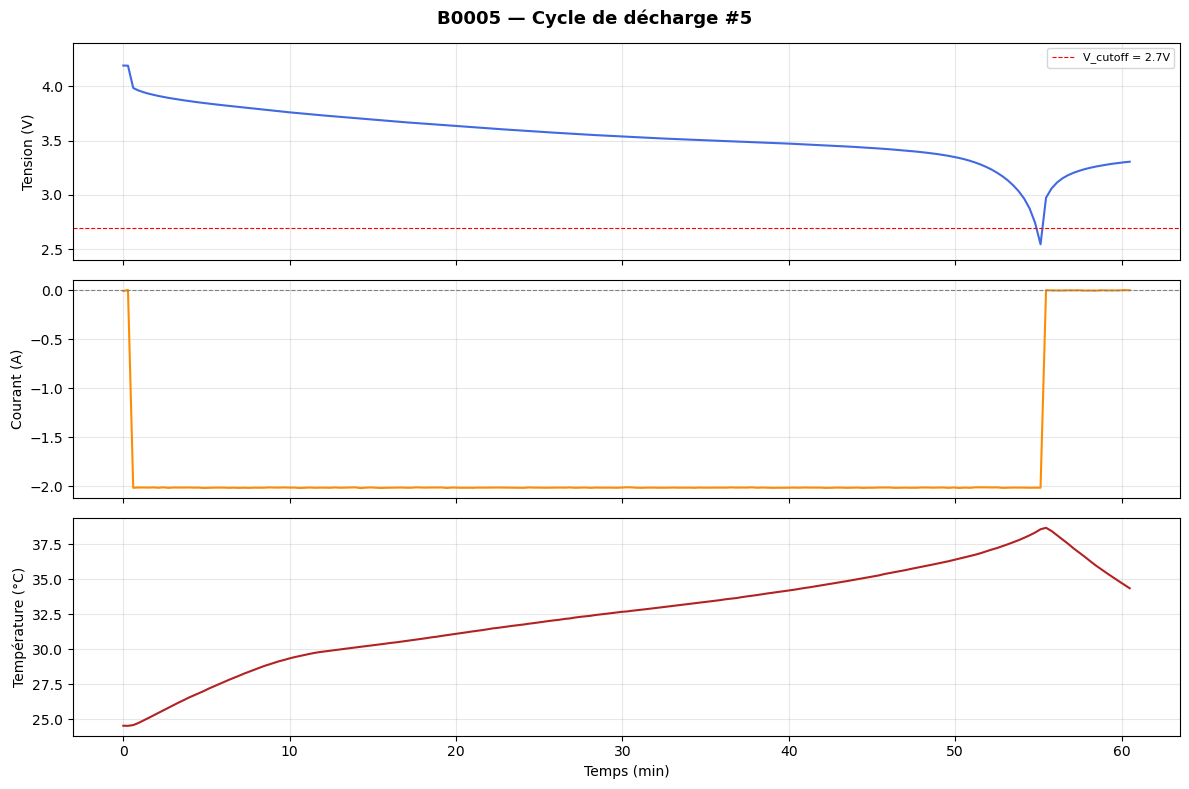

Sauvegardé → data/processed/fig_01_discharge_cycle.png


In [5]:
disch_cycles = df_all[(df_all['cell'] == 'B0005') & (df_all['type'] == 'discharge')]
cycle_ids    = disch_cycles['cycle_idx'].unique()
cycle        = disch_cycles[disch_cycles['cycle_idx'] == cycle_ids[4]].copy()
cycle['time_min'] = (cycle['time_s'] - cycle['time_s'].iloc[0]) / 60

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle('B0005 — Cycle de décharge #5', fontsize=13, fontweight='bold')

axes[0].plot(cycle['time_min'], cycle['voltage_V'], color='royalblue', lw=1.5)
axes[0].set_ylabel('Tension (V)')
axes[0].set_ylim(2.4, 4.4)
axes[0].axhline(2.7, color='red', ls='--', lw=0.8, label='V_cutoff = 2.7V')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(cycle['time_min'], cycle['current_A'], color='darkorange', lw=1.5)
axes[1].set_ylabel('Courant (A)')
axes[1].axhline(0, color='gray', ls='--', lw=0.8)
axes[1].grid(True, alpha=0.3)

axes[2].plot(cycle['time_min'], cycle['temp_C'], color='firebrick', lw=1.5)
axes[2].set_ylabel('Température (°C)')
axes[2].set_xlabel('Temps (min)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_PROC / 'fig_01_discharge_cycle.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé → data/processed/fig_01_discharge_cycle.png')

## 5. Coulomb Counting — Première estimation du SOC

### Théorie

$$SOC(t) = SOC_0 + \frac{1}{Q_{nom}} \int_0^t \eta \cdot I(\tau)\, d\tau$$

- $Q_{nom}$ : capacité nominale (Ah)
- $\eta$ : efficacité coulombique (≈ 1 pour LCO)
- $I > 0$ : charge, $I < 0$ : décharge

**Limite principale** : dérive cumulative si le courant est mal calibré.  
C'est pour ça qu'on passera ensuite au **Filtre de Kalman Étendu** (EKF) qui corrige cette dérive.

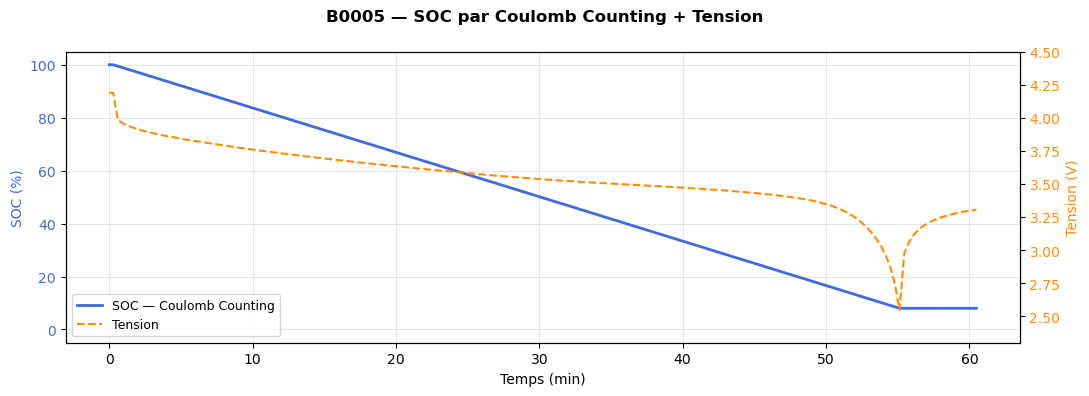

SOC initial : 100.0%  |  SOC final : 8.0%
Charge extraite : 1840 mAh


In [6]:
def coulomb_counting(time_s, current_A, Q_nom_Ah, soc0=1.0, eta=1.0):
    """Estimation SOC par intégration d'ampères-heures (trapèzes)."""
    Q_nom_As = Q_nom_Ah * 3600
    dt  = np.diff(time_s, prepend=time_s[0])
    dQ  = eta * current_A * dt
    soc = soc0 + np.cumsum(dQ) / Q_nom_As
    return np.clip(soc, 0.0, 1.0)


Q_nom = 2.0  # Ah — capacité nominale B0005
t   = cycle['time_s'].values
I   = cycle['current_A'].values
V   = cycle['voltage_V'].values
soc = coulomb_counting(t, I, Q_nom_Ah=Q_nom, soc0=1.0)
t_min = (t - t[0]) / 60

fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.set_xlabel('Temps (min)')
ax1.set_ylabel('SOC (%)', color='royalblue')
ax1.plot(t_min, soc * 100, color='royalblue', lw=2, label='SOC — Coulomb Counting')
ax1.set_ylim(-5, 105)
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.set_ylabel('Tension (V)', color='darkorange')
ax2.plot(t_min, V, color='darkorange', lw=1.5, ls='--', label='Tension')
ax2.set_ylim(2.3, 4.5)
ax2.tick_params(axis='y', labelcolor='darkorange')

fig.suptitle('B0005 — SOC par Coulomb Counting + Tension', fontsize=12, fontweight='bold')
l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lb1 + lb2, loc='lower left', fontsize=9)
plt.tight_layout()
plt.savefig(DATA_PROC / 'fig_02_soc_coulomb_counting.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'SOC initial : {soc[0]*100:.1f}%  |  SOC final : {soc[-1]*100:.1f}%')
print(f'Charge extraite : {(soc[0]-soc[-1])*Q_nom*1000:.0f} mAh')

## 6. Dégradation de Capacité — Aperçu du SOH

$$SOH(n) = \frac{Q_n}{Q_{nominal}} \times 100\%$$

La fin de vie (EOL) est fixée à **SOH = 80%** → **1.6 Ah** pour ces cellules.

In [7]:
Q_NOMINAL = 2.0
colors    = ['royalblue', 'darkorange', 'seagreen', 'crimson']
fig       = go.Figure()

for cell, color in zip(CELLS, colors):
    disch = df_summ[(df_summ['cell'] == cell) & (df_summ['type'] == 'discharge')].copy()
    disch = disch.dropna(subset=['capacity_Ah'])
    disch['cycle_num'] = range(1, len(disch) + 1)
    disch['SOH_pct']   = disch['capacity_Ah'] / Q_NOMINAL * 100

    fig.add_trace(go.Scatter(
        x=disch['cycle_num'], y=disch['SOH_pct'],
        name=cell, line=dict(color=color, width=2),
        mode='lines+markers', marker=dict(size=3)
    ))

fig.add_hline(y=80, line_dash='dash', line_color='red',
              annotation_text='EOL — 80% SOH', annotation_position='bottom right')
fig.update_layout(
    title='Capacity Fade — Dégradation SOH par cycle (4 cellules NASA)',
    xaxis_title='Numéro de cycle', yaxis_title='SOH (%)',
    yaxis=dict(range=[60, 105]), legend_title='Cellule',
    template='plotly_white', height=450
)
fig.show()
fig.write_html(str(DATA_PROC / 'fig_03_capacity_fade.html'))
print('Sauvegardé → data/processed/fig_03_capacity_fade.html')

Sauvegardé → data/processed/fig_03_capacity_fade.html


## 7. Courbe OCV–SOC

La courbe **OCV–SOC** est la carte d'identité électrique de la cellule.  
Elle sera utilisée dans l'ECM et dans le filtre de Kalman comme équation de mesure : `z = OCV(SOC)`.

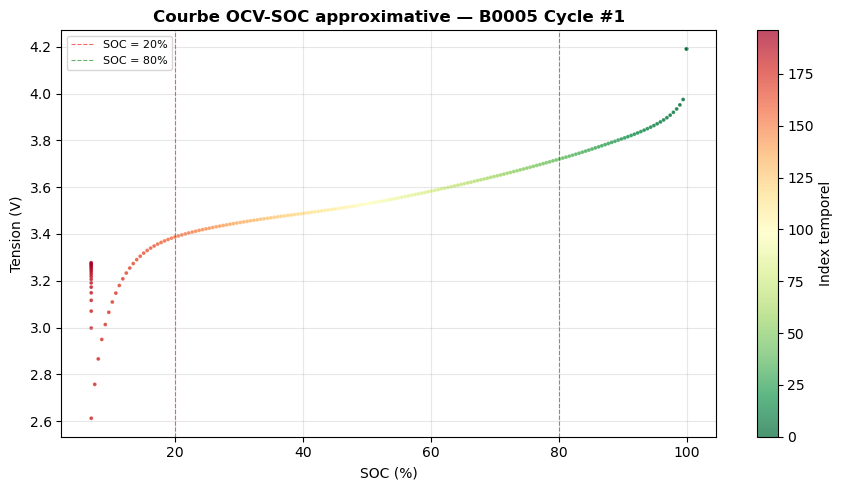

In [8]:
disch_b05 = df_all[(df_all['cell'] == 'B0005') & (df_all['type'] == 'discharge')]
cycle_ids = disch_b05['cycle_idx'].unique()
ref       = disch_b05[disch_b05['cycle_idx'] == cycle_ids[0]].copy()

t_ref   = ref['time_s'].values
V_ref   = ref['voltage_V'].values
I_ref   = ref['current_A'].values
soc_ref = coulomb_counting(t_ref, I_ref, Q_nom_Ah=Q_nom, soc0=1.0)

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(soc_ref * 100, V_ref, c=np.arange(len(soc_ref)),
                cmap='RdYlGn_r', s=3, alpha=0.7)
plt.colorbar(sc, ax=ax, label='Index temporel')
ax.set_xlabel('SOC (%)')
ax.set_ylabel('Tension (V)')
ax.set_title('Courbe OCV-SOC approximative — B0005 Cycle #1', fontweight='bold')
ax.axvline(20, color='red',   ls='--', lw=0.8, alpha=0.6, label='SOC = 20%')
ax.axvline(80, color='green', ls='--', lw=0.8, alpha=0.6, label='SOC = 80%')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(DATA_PROC / 'fig_04_ocv_soc.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Export des données nettoyées

In [9]:
try:
    import pyarrow
    df_all.to_parquet(DATA_PROC  / 'nasa_all_cycles.parquet', index=False)
    df_summ.to_parquet(DATA_PROC / 'nasa_summary.parquet',    index=False)
    fmt = 'parquet'
except ImportError:
    df_all.to_csv(DATA_PROC  / 'nasa_all_cycles.csv', index=False)
    df_summ.to_csv(DATA_PROC / 'nasa_summary.csv',    index=False)
    fmt = 'csv'

print(f'Format : {fmt}')
for f in sorted(DATA_PROC.glob(f'nasa_*.{fmt}')):
    print(f'  {f.name}  — {f.stat().st_size / 1e6:.1f} MB')

print()
print(df_summ.groupby(['cell','type']).size().reset_index(name='nb_cycles').to_string(index=False))

Format : parquet
  nasa_all_cycles.parquet  — 62.8 MB
  nasa_summary.parquet  — 0.1 MB

 cell      type  nb_cycles
B0005    charge        170
B0005 discharge        168
B0006    charge        170
B0006 discharge        168
B0007    charge        170
B0007 discharge        168
B0018    charge        134
B0018 discharge        132


## 9. Statistiques globales

In [10]:
stats = df_all.groupby('cell').agg(
    V_moy=('voltage_V', 'mean'),
    V_min=('voltage_V', 'min'),
    V_max=('voltage_V', 'max'),
    I_moy=('current_A', 'mean'),
    T_moy=('temp_C',    'mean'),
    T_max=('temp_C',    'max'),
).round(3)

print('Statistiques par cellule :')
print(stats.to_string())
print('\n--- Notebook 01 TERMINE ---')
print('Suivant : 02_ecm_simulation.ipynb — Modele Thevenin 2RC')

Statistiques par cellule :
       V_moy  V_min  V_max  I_moy   T_moy   T_max
cell                                             
B0005  4.104  0.003  8.393  0.369  26.370  41.450
B0006  4.104 -0.001  8.083  0.359  26.429  42.008
B0007  4.100  0.003  8.333  0.387  26.119  42.333
B0018  4.077  2.279  4.300  0.306  25.913  38.879

--- Notebook 01 TERMINE ---
Suivant : 02_ecm_simulation.ipynb — Modele Thevenin 2RC


---
## Résumé

| Étape | Résultat |
|-------|----------|
| Chargement `.mat` | 4 cellules, ~130–168 cycles chacune |
| Parsing | DataFrame propre : V, I, T, t par cycle |
| Coulomb Counting | SOC 100% → 0% en décharge |
| Capacity Fade | Dégradation visible dès le cycle 50–60 |
| OCV–SOC | Courbe caractéristique LCO extraite |
| Export | `nasa_all_cycles` + `nasa_summary` sauvegardés |

**Notebook suivant →** `02_ecm_simulation.ipynb`  
Modèle Thevenin 2RC : ton cours de circuits RC appliqué à la batterie,  
identification des paramètres R0, R1, C1, R2, C2 depuis les données réelles.